In [ ]:
from Functions import DataRetrieval as DR
import os
import requests
import logging
import time
from dateutil.relativedelta import relativedelta
from concurrent.futures import ThreadPoolExecutor, as_completed
from Reference_files.keys import NCBI_API_KEY as NCBI_API_KEY
import matplotlib.pyplot as plt
import csv
import pandas as pd 
import numpy as np 
from tqdm.auto import tqdm
from eutils import EutilsNCBIError, EutilsRequestError
from datetime import datetime
from tqdm.auto import tqdm
#Import DR module from Functions folder
from Functions import DataRetrieval as DR
#API_KEY
import urllib
import json
import random
from typing import List, Dict, Optional, Tuple
from ratelimit import limits, sleep_and_retry
import re

/home/naji01/miniconda3/envs/ip-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Query construction from filters
O = '''("english"[Language] 
NOT "meta-analysis"[Publication Type] 
NOT "review"[Publication Type] 
NOT "retracted publication"[Publication Type] 
NOT "retraction of publication"[Publication Type] 
NOT "published erratum"[Publication Type] 
NOT "controlled clinical trial"[Publication Type] 
NOT "clinical study"[Publication Type] 
NOT "clinical trial"[Publication Type] 
NOT "clinical trial protocol"[Publication Type] 
NOT "clinical trial, phase i"[Publication Type] 
NOT "clinical trial, phase ii"[Publication Type] 
NOT "clinical trial, phase iii"[Publication Type] 
NOT "clinical trial, phase iv"[Publication Type] 
NOT "clinical trial, veterinary"[Publication Type])'''

A1 = '''"nucleoproteins"[MeSH Terms] 
OR "protein interaction mapping"[MeSH Terms] OR ("nucleoprotein"[All Fields] 
OR "nucleoproteins"[All Fields] 
OR "multiprotein"[All Fields] 
OR "multiproteins"[All Fields] 
OR "proteins"[MeSH Terms] 
OR "protein"[All Fields] 
OR "proteins"[All Fields] 
OR "enzyme"[All Fields]) 
AND 
("interact"[All Fields] 
OR "interacted"[All Fields] 
OR "interacting"[All Fields] 
OR "interaction"[All Fields] 
OR "interactions"[All Fields] 
OR "interactivity"[All Fields] 
OR "interacts"[All Fields]) OR ("protein interaction"[All Fields] 
OR "protein interactions"[All Fields] 
OR "interacting protein"[All Fields] 
OR "interacting proteins"[All Fields] OR "multiprotein complexes"[MeSH Terms]) OR
("nucleoprotein"[All Fields] 
OR "nucleoproteins"[All Fields] 
OR "multiprotein"[All Fields] 
OR "multiproteins"[All Fields] 
OR "proteins"[MeSH Terms] 
OR "protein"[All Fields] 
OR "proteins"[All Fields] 
OR "enzyme"[All Fields]) 
AND 
("complex"[All Fields] 
OR "complexes"[All Fields] 
OR "heteromer"[All Fields] 
OR "heteromers"[All Fields] 
OR "homomer"[All Fields] 
OR "homomers"[All Fields] 
OR "heteromeric"[All Fields] 
OR "homomeric"[All Fields] 
OR "subunit"[All Fields] 
OR "subunits"[All Fields])
OR "protein complex"[All Fields] 
OR "protein complexes"[All Fields] OR ("protein"[All Fields] 
AND ("RNA"[All Fields] 
OR "DNA"[All Fields] 
OR "ribonucleic"[All Fields] 
OR "deoxyribonucleic"[All Fields]) 
AND ("interaction"[All Fields] 
OR "interactions"[All Fields] ))'''

A2 = '''"Immunoprecipitation"[Mesh] 
OR coimmunoprecipitation 
OR ("co"[All Fields] AND "immunoprecipitation"[All Fields]) 
OR ("RNA" [All Fields] AND "immunoprecipitation" [All Fields]) 
OR "co immunoprecipitation"[All Fields] OR "coIP"[All Fields] OR "Chromatography, Affinity"[Mesh] OR "affinity purification"[All Fields] OR "affinity isolation"[All Fields] OR "affinity chromatography"[All Fields] 
OR ("affinity"[All Fields] AND ("purification"[All Fields] OR "isolation"[All Fields] OR "chromatography"[All Fields])) 
OR("pull"[All Fields] AND ("down"[All Fields] OR "downs"[All Fields]))'''


A3 = '''"crystallography, x ray"[MeSH Terms]
OR "Nuclear Magnetic Resonance, Biomolecular"[MeSH Terms]
OR "Cryoelectron Microscopy"[MeSH Terms]
OR "Protein Array Analysis"[MeSH Terms]
OR "electrophoretic mobility shift assay"[MeSH Terms] 
OR "Surface Plasmon Resonance"[MeSH Terms]'''

B = '''"Epitope Mapping"[MeSH Terms] 
OR "Precipitin Tests"[MeSH Terms] 
OR "Two-Hybrid System Techniques"[MeSH Terms] 
OR "blotting, far western"[MeSH Terms] 
OR "Radioimmunoprecipitation Assay"[MeSH Terms] 
OR "Autoantibodies"[MeSH Terms] 
OR "Chromatin Immunoprecipitation"[MeSH Terms] 
OR "Cross-Linking Reagents"[MeSH Terms] 
OR "Formaldehyde"[MeSH Terms] 
OR "Microscopy"[MeSH Terms]OR (crosslink AND reagent) 
OR "Formaldehyde"[All Fields] OR "DNA Footprinting"[Mesh] 
OR "Nuclease Protection Assays"[Mesh]  
OR "Blotting, Southwestern"[Mesh] 
OR "Fluorescence Resonance Energy Transfer"[Mesh] 
OR "PAR CLIP"[All Fields]
OR "AlphaFold"[All Fields]'''



query = f"({O} AND ({A1} OR {A3})) NOT ({A1} AND {B} NOT ({A2} AND {A3}))"

Generating date batches...
Generating year-aligned batches with internal windowing from 2010-09-01 to 2025-09-16...


 Total batches generated: 104
Estimated total papers across all batches margin is 30%: 886063
Plotting the density of papers over time....
Fetching the list of PMIDs....
Total unique PMIDs fetched: 589957
Batch metadata summary:
  2010-11-01 to 2010-12-31: 9345 papers
  2010-09-01 to 2010-10-31: 9120 papers
  2011-01-01 to 2011-01-21: 7041 papers
  2011-01-22 to 2011-03-23: 9470 papers
  2011-03-24 to 2011-05-23: 9301 papers
  2011-05-24 to 2011-07-23: 9265 papers
  2011-07-24 to 2011-09-22: 9011 papers
  2011-09-23 to 2011-11-22: 9190 papers
  2011-11-23 to 2011-12-31: 5612 papers
  2012-01-01 to 2012-01-21: 9656 papers
  2012-01-22 to 2012-03-22: 9207 papers
  2012-03-23 to 2012-05-22: 8956 papers
  2012-05-23 to 2012-07-22: 8915 papers
  2012-07-23 to 2012-09-21: 9146 papers
  2012-09-22 to 2012-11-21: 9024 papers
  2012-11-22 to 2012-12-31: 5461 papers
  2013-01-01 

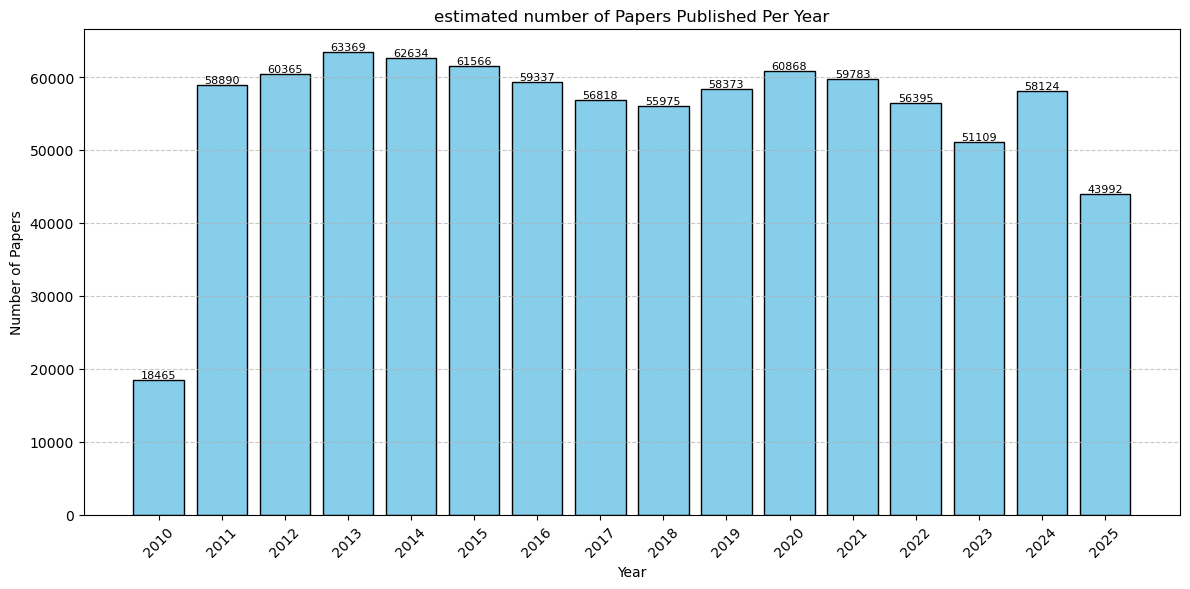

In [5]:
papers = DR.fetch_pmids_over_period(
    query_file="./Reference_files/query.txt",
    start="2010-09-01",
    stop=None,
    plot= True,
    full_text=False,
)

In [ ]:
annotation_app_papers = , ""]

 "Native holdup (nHU) to measure binding affinities from cell extracts" -- WHY: Innovative "reverse-IP" method, not all protocols can be imagined.

In [ ]:
pmid_pmc = DR.pmid2pmcid(papers, 'email@gmail.com')

# fetch metadata from entrez
PMID,PMCID,Title,Abstract,Authors,ISSN,Issue,Volume, Dates, Journal Title Abbreviation,Journal Title,Combined Terms (MH+OT+RN+NM)

In [6]:
data = DR.fetch_parse_pubmed_metadata(papers)

Processing PMID Chunks: 100%|██████████| 60/60 [09:02<00:00,  9.04s/chunk] 


# flag OA papers from our metadata

In [9]:
oa_flagged = DR.filter_df_oa_database(data) # downloads open access database file from NCBI server \size: ~230 mgb\

In [ ]:
oa_flagged.to_csv("metadata_oa_flagged", index=False)

## Download papers using python requests

In [6]:
oa_pmcids = ["PMC9770967"]

In [ ]:
success_count, failed = DR.download_pmc_articles(oa_pmcids)


Download Summary:
Successfully processed 1/1 full-text files


###  Or download using powershell \windows/faster\ 

In [ ]:
# Save the oa_pmcids pandas series to a text file that powershell can read(one ID per line)
mkdir -p ./Full_text_jsons

# Read PMCIDs from the file and process each one
Get-Content oa_pmcids.txt | ForEach-Object {
    $pmcid = $_

    # 1. Download full-text JSON
    $jsonUrl = "https://www.ncbi.nlm.nih.gov/research/bionlp/RESTful/pmcoa.cgi/BioC_json/$pmcid/unicode"
    $jsonOut = "./Full_text_jsons/$pmcid.json"
    Invoke-RestMethod -Uri $jsonUrl -OutFile $jsonOut

    # 2. Download supplementary ZIP
    $zipUrl = "https://www.ebi.ac.uk/europepmc/webservices/rest/$pmcid/supplementaryFiles"
    $zipOut = "./Full_text_jsons/${pmcid}_supp.zip"
    Invoke-WebRequest -Uri $zipUrl -OutFile $zipOut
}

# Or Using bash

In [ ]:
%%bash

mkdir -p ./Full_text_jsons

while IFS= read -r PMCID; do
    echo "Processing $PMCID"

    # 1. Download full-text JSON
    json_url="https://www.ncbi.nlm.nih.gov/research/bionlp/RESTful/pmcoa.cgi/BioC_json/${PMCID}/unicode"
    curl -s "${json_url}" -o "./Full_text_jsons/${PMCID}.json"

done < full_text_pmc.txt


### add publishers if needed using Xreff

In [ ]:
added_publishers = DR.process_publishers_concurrent(data, email="email@rockefeller.edu")

Fetching publishers by DOI/ISSN: 100%|██████████| 7/7 [00:02<00:00,  2.62it/s]


# process full text json and parse relevant data into a dataframe 

In [8]:
section_types = ['TITLE', 'ABSTRACT', 'INTRO', 'METHODS', 'RESULTS', 'CONCL', 'FIG', 'SUPPL', 'DISCUSS']
full_text_df = DR.extract_text_from_json_to_dataframe("./Full_text_jsons", section_types)

2025-05-28 18:50:12 LAPTOP-S8N3C7A8 Functions.DataRetrieval[21192] INFO Extracting from JSON files in ./Full_text_jsons
2025-05-28 18:50:12 LAPTOP-S8N3C7A8 Functions.DataRetrieval[21192] INFO Processed 1 files, 0 errors
2025-05-28 18:50:12 LAPTOP-S8N3C7A8 Functions.DataRetrieval[21192] INFO Extracted 100 entries


# BioC supplementary

# Creat full_text table + supplementary 

In [ ]:
full_text_df = DR.extract_text_from_json_to_dataframe("./XML+JSON", section_types, "./XML+JSON")